## Logistic Regression
- The notebook implements a logistic regression model to classify bank notes as 'authentic' or 'fake'
- We use a data set with the following features;
    - Variance of Wavelet Transformed image (continuous)
    - Skewness of Wavelet Transformed image (continuous)
    - Curtosis of Wavelet Transformed image (continuous)
    - Entropy of image (continuous)
    - Class (integer)
- Total Instance : 1372
- Data Source
    - https://archive.ics.uci.edu/ml/datasets/banknote+authentication

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn import preprocessing

In [2]:
path = "Data\BankNotes_Training.csv"
df = pd.read_csv(path)
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\B'
<>:1: SyntaxWarning: invalid escape sequence '\B'
C:\Users\iftikhar.Ahmed\AppData\Local\Temp\ipykernel_8800\2912934483.py:1: SyntaxWarning: invalid escape sequence '\B'
  path = "Data\BankNotes_Training.csv"


,Variance,Skewness,Curtosis,Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [3]:
df.shape

(1372, 5)

In [4]:
df.columns

Index(['Variance', 'Skewness', 'Curtosis', 'Entropy', 'Class'], dtype='object')

In [5]:
df.dtypes

Variance    float64
Skewness    float64
Curtosis    float64
Entropy     float64
Class         int64
dtype: object

In [6]:
df.shape

(1372, 5)

In [7]:
df["Class"].value_counts()

Class
0    762
1    610
Name: count, dtype: int64

In [8]:
X = df.iloc[:, :-1]

Y = df.iloc[:,4] #Y = df.iloc[:,-1]

In [9]:
X

,Variance,Skewness,Curtosis,Entropy
0,3.62160,8.66610,-2.8073,-0.44699
1,4.54590,8.16740,-2.4586,-1.46210
2,3.86600,-2.63830,1.9242,0.10645
3,3.45660,9.52280,-4.0112,-3.59440
4,0.32924,-4.45520,4.5718,-0.98880
...,...,...,...,...
1367,0.40614,1.34920,-1.4501,-0.55949
1368,-1.38870,-4.87730,6.4774,0.34179
1369,-3.75030,-13.45860,17.5932,-2.77710
1370,-3.56370,-8.38270,12.3930,-1.28230


In [10]:
Y

0       0
1       0
2       0
3       0
4       0
       ..
1367    1
1368    1
1369    1
1370    1
1371    1
Name: Class, Length: 1372, dtype: int64

In [11]:
X.describe()

,Variance,Skewness,Curtosis,Entropy
count,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657
std,2.842763,5.869047,4.310030,2.101013
min,-7.042100,-13.773100,-5.286100,-8.548200
25%,-1.773000,-1.708200,-1.574975,-2.413450
50%,0.496180,2.319650,0.616630,-0.586650
75%,2.821475,6.814625,3.179250,0.394810
max,6.824800,12.951600,17.927400,2.449500


In [12]:
from sklearn.preprocessing import RobustScaler
scaler =  preprocessing.RobustScaler()
X = scaler.fit_transform(X)

In [13]:
def sum(x,y):
    '''
    This is the help section where nothing is working 
    '''
    return x+y

In [14]:
help(sum)

Help on function sum in module __main__:

sum(x, y)
    This is the help section where nothing is working



In [15]:
help(RobustScaler)

Help on class RobustScaler in module sklearn.preprocessing._data:

class RobustScaler(sklearn.base.OneToOneFeatureMixin, sklearn.base.TransformerMixin, sklearn.base.BaseEstimator)
 |  RobustScaler(*, with_centering=True, with_scaling=True, quantile_range=(25.0, 75.0), copy=True, unit_variance=False)
 |
 |  Scale features using statistics that are robust to outliers.
 |
 |  This Scaler removes the median and scales the data according to
 |  the quantile range (defaults to IQR: Interquartile Range).
 |  The IQR is the range between the 1st quartile (25th quantile)
 |  and the 3rd quartile (75th quantile).
 |
 |  Centering and scaling happen independently on each feature by
 |  computing the relevant statistics on the samples in the training
 |  set. Median and interquartile range are then stored to be used on
 |  later data using the :meth:`transform` method.
 |
 |  Standardization of a dataset is a common preprocessing for many machine
 |  learning estimators. Typically this is done by 

In [16]:
X

array([[ 0.68025618,  0.74464159, -0.72018678,  0.04973186],
       [ 0.88143259,  0.68612813, -0.64684149, -0.31174108],
       [ 0.7334505 , -0.58172613,  0.27503326,  0.24680763],
       ...,
       [-0.92425794, -1.85129344,  3.57083857, -0.78000256],
       [-0.88364394, -1.255728  ,  2.47703253, -0.24771567],
       [-0.66124639, -0.34937829,  0.43489107,  0.63450322]],
      shape=(1372, 4))

# Data Splitting

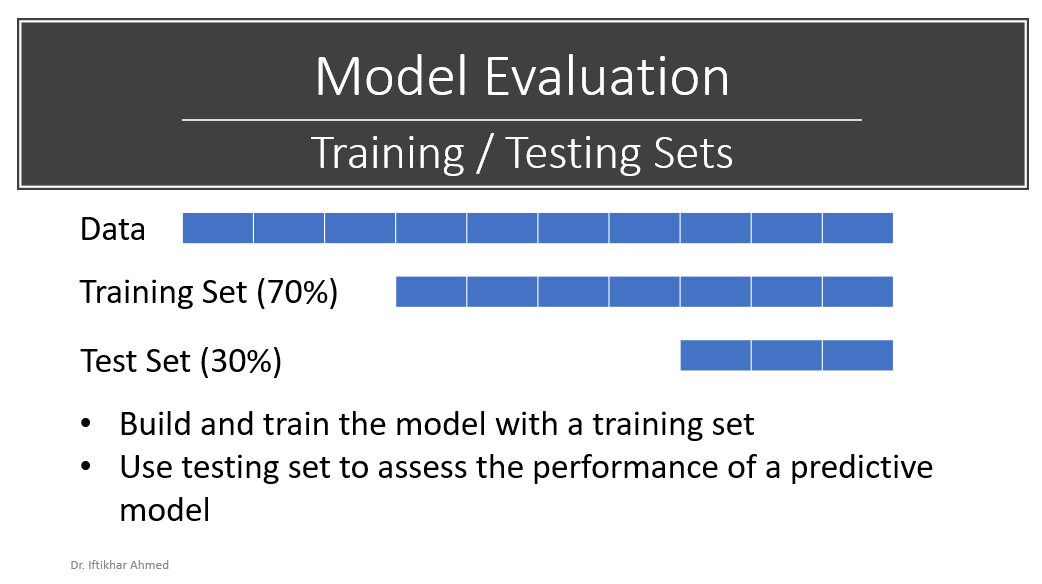

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=0)

In [18]:
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(960, 4)
(960,)
(412, 4)
(412,)


In [19]:
model = LogisticRegression()

model.fit(X_train,Y_train)

print(model.intercept_)
print(model.coef_)

[-0.68338759]
[[-6.19398943 -5.49907186 -3.82544583  0.17205518]]


In [20]:
# Training Accuracy
score = model.score(X_train, Y_train)
score

0.98125

In [21]:
# Test Accuracy
score = model.score(X_test, Y_test)
score

0.9830097087378641

## Evalutation Measures

### Confusion Matrix
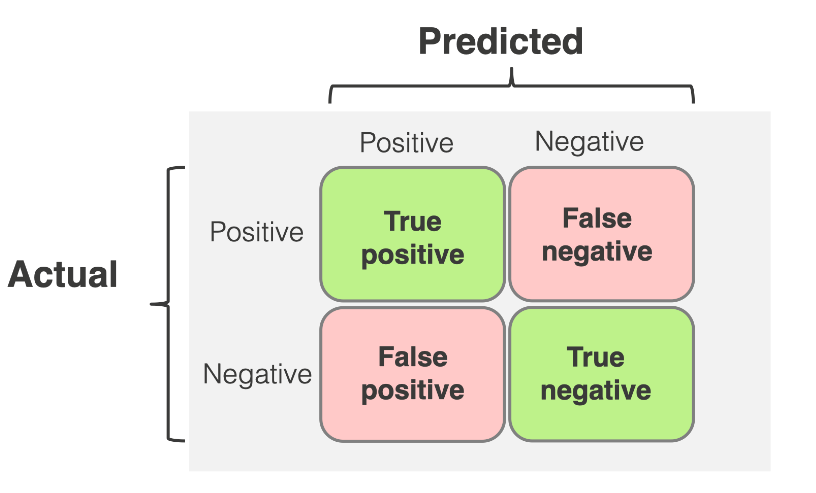

Image Source : https://www.evidentlyai.com/classification-metrics/confusion-matrix

### Accuracy :  $ \frac{TP + TN}{TP + FN + FP + TN}$
  
### Precision : $ \frac{TP }{TP  + FP }$

### Recall : $ \frac{TP }{TP  + FN }$

### F1-Score : $ 2 \cdot \frac{Precision \cdot Recall }{Precision + Recall }$

In [22]:
Y_pred_train = model.predict(X_train)

accuracy = accuracy_score(Y_train, Y_pred_train)
recall = recall_score(Y_train, Y_pred_train)
precision = precision_score(Y_train, Y_pred_train)
f1 = f1_score(Y_train, Y_pred_train)

print("Training Performance.....")
print(f"Accuracy: {accuracy:0.3f}")
print(f"Recall: {recall:.3f}")
print(f"Precision: {precision:.3f}")
print(f"F1-score: {f1:.3f}")
print("....................")

Training Performance.....
Accuracy: 0.981
Recall: 0.995
Precision: 0.964
F1-score: 0.979
....................


In [23]:
Y_pred = model.predict(X_test)

accuracy = accuracy_score(Y_test, Y_pred)
recall = recall_score(Y_test, Y_pred)
precision = precision_score(Y_test, Y_pred)
f1 = f1_score(Y_test, Y_pred)

print("Test Performance.....")
print(f"Accuracy: {accuracy:0.3f}")
print(f"Recall: {recall:.3f}")
print(f"Precision: {precision:.3f}")
print(f"F1-score: {f1:.3f}")
print("....................")

Test Performance.....
Accuracy: 0.983
Recall: 1.000
Precision: 0.963
F1-score: 0.981
....................


## Visualizing Confusion Matrix

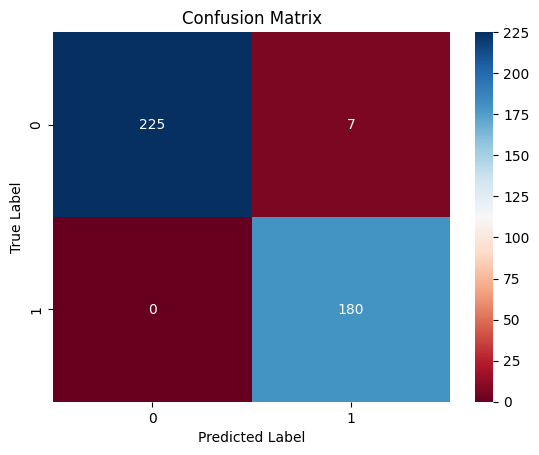

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Create confusion matrix
cm = confusion_matrix(Y_test, Y_pred)

# Using seaborn for visulazing confusion matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="RdBu") # cmap = "YlOrBr" RdBu, 
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()





In [25]:
# Visualize as a table
import pandas as pd
df_cm = pd.DataFrame(cm, index=[0, 1], columns=[0, 1])
df_cm.index.name = "True Label"
df_cm.columns.name = "Predicted Label"
print(df_cm)

Predicted Label    0    1
True Label               
0                225    7
1                  0  180
